<a href="https://colab.research.google.com/github/cavalcantiju/ex1_DS_hotel/blob/main/pratica1_DS_hotel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
import pandas as pd


In [60]:
dados = pd.read_csv('hoteis.csv')

In [61]:
dados.head()

,Estrelas,ProximidadeTurismo,Capacidade,Preco
0,5,9.301565,3,506.275452
1,1,1.785891,1,246.363458
2,4,15.504293,3,325.873550
3,4,4.173188,3,521.343284
4,4,9.443685,1,252.587087


In [62]:
corr = dados.corr()
corr['Preco']

,Preco
Estrelas,0.401099
ProximidadeTurismo,-0.697142
Capacidade,0.531866
Preco,1.000000


In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

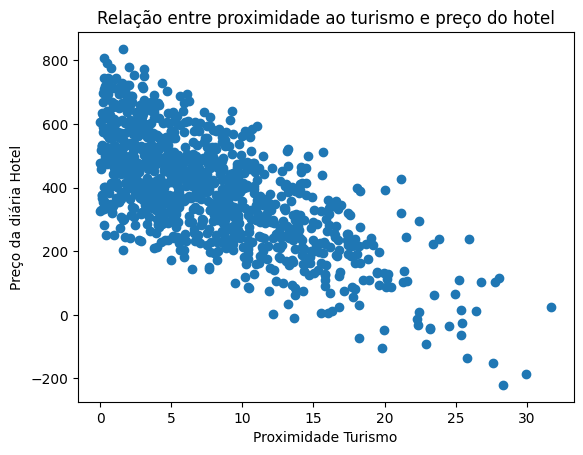

In [64]:
plt.scatter(x=dados['ProximidadeTurismo'], y=dados['Preco'])
plt.title("Relação entre proximidade ao turismo e preço do hotel")
plt.xlabel("Proximidade Turismo")
plt.ylabel("Preço da diária Hotel")
plt.show()

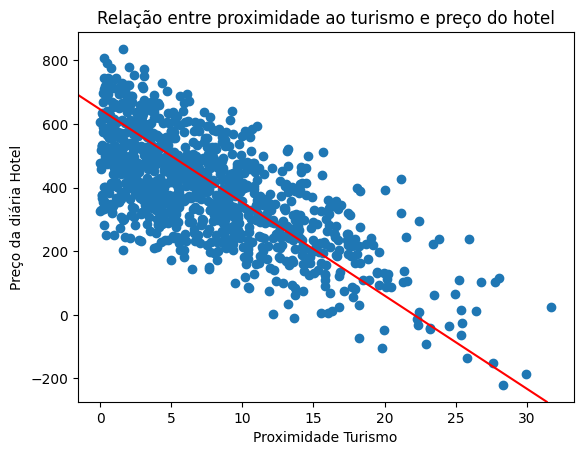

In [65]:
plt.scatter(x=dados['ProximidadeTurismo'], y=dados['Preco'])
plt.axline(xy1 = (5, 500), xy2 = (26, -115), color = 'red') #escolhi os pontos por olho
plt.title("Relação entre proximidade ao turismo e preço do hotel")
plt.xlabel("Proximidade Turismo")
plt.ylabel("Preço da diária Hotel")
plt.show()

In [66]:
#QUAL A MELHOR RETA?
px.scatter(dados, x = "ProximidadeTurismo", y = "Preco", trendline_color_override= "red", trendline = 'ols')

In [67]:
x = dados[['Estrelas', 'ProximidadeTurismo', 'Capacidade']]
y = dados['Preco']

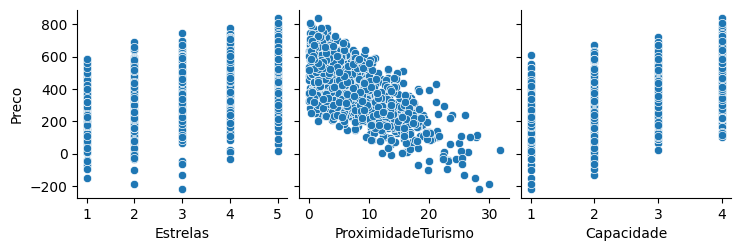

In [68]:
sns.pairplot(dados, y_vars = 'Preco', x_vars = ['Estrelas', 'ProximidadeTurismo', 'Capacidade'])

In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

In [79]:
print(len(X_train))
print(len(y_train))

800
800


In [82]:
import pandas as pd
from statsmodels.formula.api import ols

#  Criamos o DataFrame de treino com as colunas de X e Y
df_train = pd.DataFrame(data=X_train)
df_train['Preco'] = y_train

df_train.head()

modelo_0 = ols('Preco ~ Estrelas + ProximidadeTurismo + Capacidade', data = df_train).fit()
modelo_0.params

,0
Intercept,192.827253
Estrelas,50.410899
ProximidadeTurismo,-19.911331
Capacidade,80.945288


In [83]:
print(modelo_0.summary())

                            OLS Regression Results                            
Dep. Variable:                  Preco   R-squared:                       0.923
Model:                            OLS   Adj. R-squared:                  0.922
Method:                 Least Squares   F-statistic:                     3162.
Date:                Mon, 16 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:58:38   Log-Likelihood:                -4226.6
No. Observations:                 800   AIC:                             8461.
Df Residuals:                     796   BIC:                             8480.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            192.8273      6

In [88]:
from sklearn.metrics import r2_score

modelo_1 = ols('Preco ~ Estrelas', data = df_train).fit()
modelo_2 = ols('Preco ~  ProximidadeTurismo', data = df_train).fit()
modelo_3 = ols('Preco ~ Capacidade', data = df_train).fit()
modelo_4 = ols('Preco ~ ProximidadeTurismo + Capacidade', data = df_train).fit()


print("R²:")
print("Modelo 0 (Todos os x): ", modelo_0.rsquared)
print("Modelo 1 (Estrelas): ", modelo_1.rsquared)
print("Modelo 2 (Prox Turismo): ", modelo_2.rsquared)
print("Modelo 3 (Capacidade): ", modelo_3.rsquared)
print("Modelo 4 (Prox Turismo + Capacidade): ", modelo_4.rsquared)

R²:
Modelo 0 (Todos os x):  0.9225760808475094
Modelo 1 (Estrelas):  0.17037863921375196
Modelo 2 (Prox Turismo):  0.4924180738999635
Modelo 3 (Capacidade):  0.27344165751974825
Modelo 4 (Prox Turismo + Capacidade):  0.7497944723913501


In [89]:
print(modelo_1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Preco   R-squared:                       0.170
Model:                            OLS   Adj. R-squared:                  0.169
Method:                 Least Squares   F-statistic:                     163.9
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           2.92e-34
Time:                        20:04:52   Log-Likelihood:                -5175.3
No. Observations:                 800   AIC:                         1.035e+04
Df Residuals:                     798   BIC:                         1.036e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    245.7723     12.955     18.971      0.0

In [90]:
print(modelo_2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Preco   R-squared:                       0.492
Model:                            OLS   Adj. R-squared:                  0.492
Method:                 Least Squares   F-statistic:                     774.2
Date:                Mon, 16 Mar 2026   Prob (F-statistic):          1.26e-119
Time:                        20:04:58   Log-Likelihood:                -4978.7
No. Observations:                 800   AIC:                             9961.
Df Residuals:                     798   BIC:                             9971.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            552.7057      7